In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from scipy.fftpack import dct, idct
import matplotlib.pyplot as plt
from tqdm import tqdm

# -----------------------------
# PATHS
# -----------------------------
dataset_path = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/test/real_data"
generated_path = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/test/fake_data"

os.makedirs(generated_path, exist_ok=True)

IMG_SIZE = 256

In [2]:
real_files = sorted([
    f for f in os.listdir(dataset_path)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

print("Total real images:", len(real_files))

def load_rgb_image(path, size=256):
    img = Image.open(path).convert("RGB")
    img = img.resize((size, size))
    return np.array(img).astype(np.float32) / 255.0

# quick check
sample_img = load_rgb_image(os.path.join(dataset_path, real_files[0]), IMG_SIZE)
print("Sample shape:", sample_img.shape)

Total real images: 4000
Sample shape: (256, 256, 3)


In [3]:
def dct2(channel):
    return dct(dct(channel.T, norm="ortho").T, norm="ortho")

def idct2(channel):
    return idct(idct(channel.T, norm="ortho").T, norm="ortho")

def rgb_to_dct(img):
    dct_channels = []
    for c in range(3):
        dct_channels.append(dct2(img[:, :, c]))
    return np.stack(dct_channels, axis=-1)   # HWC

def dct_to_rgb(dct_img):
    rgb_channels = []
    for c in range(3):
        rgb_channels.append(idct2(dct_img[:, :, c]))
    rgb = np.stack(rgb_channels, axis=-1)
    rgb = np.clip(rgb, 0.0, 1.0)
    return rgb

In [4]:
def build_frequency_masks(size=256, low_ratio=0.10, mid_ratio=0.30):
    low_cut = max(1, int(size * low_ratio))
    mid_cut = max(low_cut + 1, int(size * mid_ratio))

    low_mask = np.zeros((size, size), dtype=np.float32)
    mid_mask = np.zeros((size, size), dtype=np.float32)
    high_mask = np.zeros((size, size), dtype=np.float32)

    # LOW
    low_mask[:low_cut, :low_cut] = 1.0

    # MID
    mid_mask[:mid_cut, :mid_cut] = 1.0
    mid_mask[:low_cut, :low_cut] = 0.0

    # HIGH
    high_mask[:, :] = 1.0
    high_mask[:mid_cut, :mid_cut] = 0.0

    return low_mask, mid_mask, high_mask

low_mask, mid_mask, high_mask = build_frequency_masks(IMG_SIZE, 0.10, 0.30)

print("Masks ready.")

Masks ready.


In [5]:
def compute_dct_band_energy_from_dct(dct_img, low_mask, mid_mask, high_mask):
    energies = {"low": 0.0, "mid": 0.0, "high": 0.0}

    for c in range(3):
        coeff = np.abs(dct_img[:, :, c])

        energies["low"] += (coeff * low_mask).sum()
        energies["mid"] += (coeff * mid_mask).sum()
        energies["high"] += (coeff * high_mask).sum()

    return energies

def compute_dct_band_energy_from_rgb(img, low_mask, mid_mask, high_mask):
    dct_img = rgb_to_dct(img)
    return compute_dct_band_energy_from_dct(dct_img, low_mask, mid_mask, high_mask)

In [10]:
def generate_frequency_perturbed_image(
    img,
    low_mask,
    mid_mask,
    high_mask,
    alpha_mid=0.10,
    alpha_high=0.30,
    low_preserve=1.00
):
    """
    Deterministic frequency amplification (NO randomness)
    Guarantees positive mid/high energy increase
    """

    dct_img = rgb_to_dct(img)
    fake_dct = dct_img.copy()

    for c in range(3):
        coeff = dct_img[:, :, c]

        # ✅ amplify existing coefficients
        scale_map = (
            low_preserve * low_mask +
            (1 + alpha_mid) * mid_mask +
            (1 + alpha_high) * high_mask
        )

        new_coeff = coeff * scale_map

        fake_dct[:, :, c] = new_coeff

    fake_img = dct_to_rgb(fake_dct)
    return fake_img, dct_img, fake_dct

Real energy: {'low': np.float32(2772.626), 'mid': np.float32(2633.2917), 'high': np.float32(3552.801)}
Fake energy: {'low': np.float32(2772.626), 'mid': np.float32(2896.621), 'high': np.float32(4618.6416)}
Diff: {'low_diff': np.float32(0.0), 'mid_diff': np.float32(263.32935), 'high_diff': np.float32(1065.8406)}


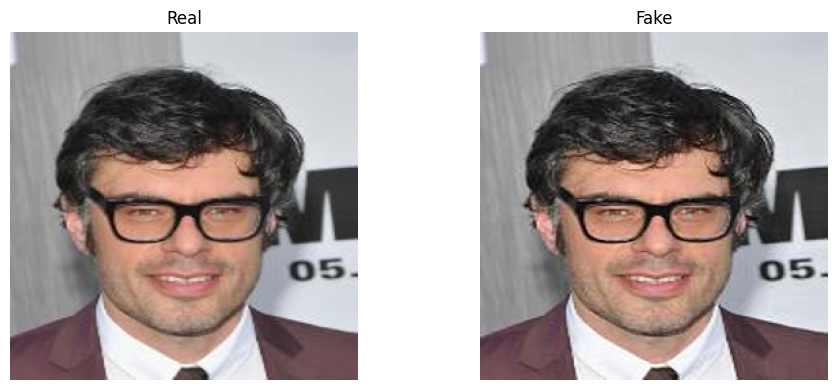

In [11]:
test_path = os.path.join(dataset_path, real_files[0])
real_img = load_rgb_image(test_path, IMG_SIZE)

fake_img, real_dct, fake_dct = generate_frequency_perturbed_image(
    real_img,
    low_mask,
    mid_mask,
    high_mask,
    alpha_mid=0.10,
    alpha_high=0.30,
    low_preserve=1.00
)

real_energy = compute_dct_band_energy_from_dct(real_dct, low_mask, mid_mask, high_mask)
fake_energy = compute_dct_band_energy_from_dct(fake_dct, low_mask, mid_mask, high_mask)

print("Real energy:", real_energy)
print("Fake energy:", fake_energy)
print("Diff:", {
    "low_diff": fake_energy["low"] - real_energy["low"],
    "mid_diff": fake_energy["mid"] - real_energy["mid"],
    "high_diff": fake_energy["high"] - real_energy["high"],
})

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(real_img)
plt.title("Real")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(fake_img)
plt.title("Fake")
plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
report_rows = []

for idx, real_name in enumerate(tqdm(real_files, desc="Generating fake images")):
    real_path = os.path.join(dataset_path, real_name)
    real_img = load_rgb_image(real_path, IMG_SIZE)

    fake_img, real_dct, fake_dct = generate_frequency_perturbed_image(
        real_img,
        low_mask,
        mid_mask,
        high_mask,
        alpha_mid=0.10,
        alpha_high=0.30,
        low_preserve=1.00,
    )

    # save fake image with same serial name + suffix
    base_name = os.path.splitext(real_name)[0]
    fake_name = f"{base_name}_fake.png"
    fake_path = os.path.join(generated_path, fake_name)

    fake_pil = Image.fromarray((fake_img * 255).astype(np.uint8))
    fake_pil.save(fake_path)

    real_energy = compute_dct_band_energy_from_dct(real_dct, low_mask, mid_mask, high_mask)
    fake_energy = compute_dct_band_energy_from_dct(fake_dct, low_mask, mid_mask, high_mask)

    report_rows.append({
        "image_id": base_name,
        "real_file": real_name,
        "fake_file": fake_name,
        "low_real": real_energy["low"],
        "mid_real": real_energy["mid"],
        "high_real": real_energy["high"],
        "low_fake": fake_energy["low"],
        "mid_fake": fake_energy["mid"],
        "high_fake": fake_energy["high"],
        "low_diff": fake_energy["low"] - real_energy["low"],
        "mid_diff": fake_energy["mid"] - real_energy["mid"],
        "high_diff": fake_energy["high"] - real_energy["high"],
    })

print("✅ Finished saving fake images.")

Generating fake images: 100%|██████████| 4000/4000 [52:14<00:00,  1.28it/s]

✅ Finished saving fake images.


Processing /content/drive/MyDrive/Colab Notebooks/thesis dataset/test/real_data: 100%|██████████| 4000/4000 [01:09<00:00, 57.83it/s] 
Processing /content/drive/MyDrive/Colab Notebooks/thesis dataset/test/fake_data: 100%|██████████| 4000/4000 [01:08<00:00, 58.69it/s]



FOLDER-LEVEL FREQUENCY REPORT

Real folder average:
  LOW: 2416.0024
  MID: 2059.4558
 HIGH: 2436.5251

Fake folder average:
  LOW: 2413.1785
  MID: 2257.0764
 HIGH: 3164.1660

Difference (Fake - Real):
  LOW: -2.8240
  MID: 197.6206
 HIGH: 727.6409

SINGLE-IMAGE FREQUENCY REPORT

Real image energy:
  LOW: 2772.6260
  MID: 2633.2920
 HIGH: 3552.8015

Fake image energy:
  LOW: 2770.5320
  MID: 2890.4028
 HIGH: 4605.2480

Difference (Fake - Real):
  LOW: -2.0940
  MID: 257.1108
 HIGH: 1052.4465


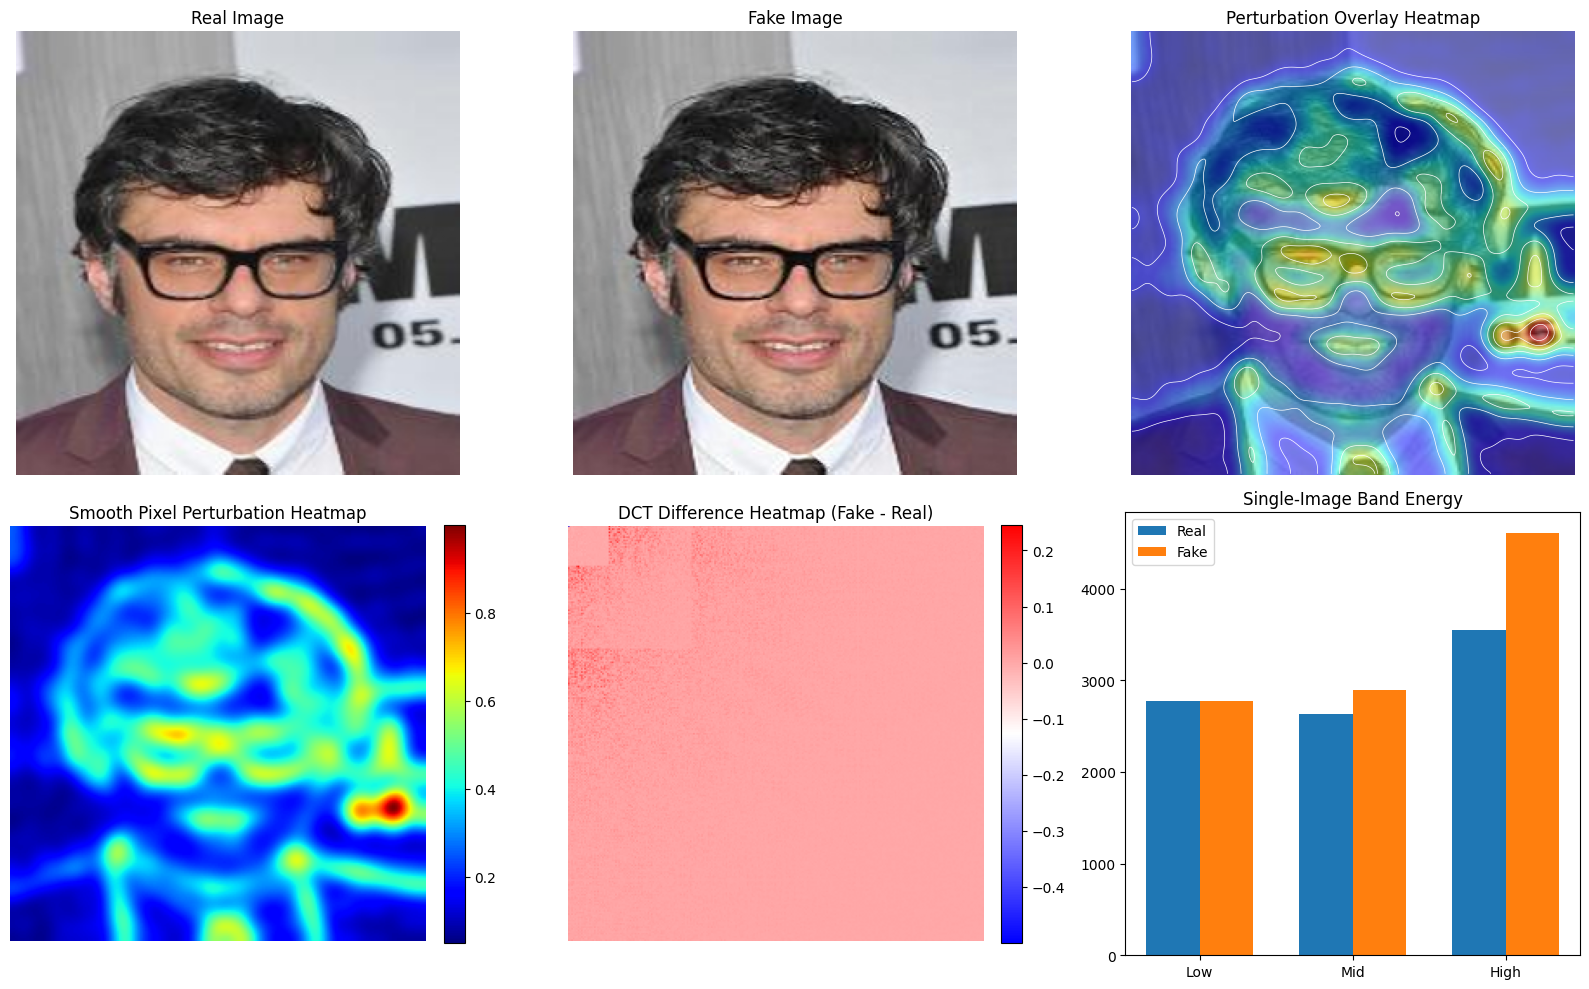


Single real path : /content/drive/MyDrive/Colab Notebooks/thesis dataset/test/real_data/027010.jpg
Single fake path : /content/drive/MyDrive/Colab Notebooks/thesis dataset/test/fake_data/027010_fake.png


In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.fftpack import dct
from scipy.ndimage import gaussian_filter
from tqdm import tqdm

# =========================================================
# CONFIG
# =========================================================
real_folder = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/test/real_data"                  # folder-level real
fake_folder = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/test/fake_data"         # folder-level fake

# MANUAL single-image paths
single_real_path = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/test/real_data/027010.jpg"          # change this
single_fake_path = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/test/fake_data/027010_fake.png"  # change this

IMG_SIZE = 256

LOW_RATIO = 0.10
MID_RATIO = 0.30
HEATMAP_SIGMA = 6

# =========================================================
# HELPERS
# =========================================================
def load_img(path, size=256):
    img = Image.open(path).convert("RGB")
    img = img.resize((size, size))
    return np.array(img).astype(np.float32) / 255.0

def dct2(channel):
    return dct(dct(channel.T, norm="ortho").T, norm="ortho")

def compute_dct_band_energy(img, low_ratio=0.10, mid_ratio=0.30):
    energies = {"low": 0.0, "mid": 0.0, "high": 0.0}

    for c in range(3):
        coeff = dct2(img[:, :, c])
        coeff = np.abs(coeff)

        h, w = coeff.shape
        low_cut = max(1, int(h * low_ratio))
        mid_cut = max(low_cut + 1, int(h * mid_ratio))

        # LOW
        low = coeff[:low_cut, :low_cut].sum()

        # MID
        mid_mask = np.zeros_like(coeff, dtype=bool)
        mid_mask[:mid_cut, :mid_cut] = True
        mid_mask[:low_cut, :low_cut] = False
        mid = coeff[mid_mask].sum()

        # HIGH
        high_mask = np.ones_like(coeff, dtype=bool)
        high_mask[:mid_cut, :mid_cut] = False
        high = coeff[high_mask].sum()

        energies["low"] += low
        energies["mid"] += mid
        energies["high"] += high

    return energies

def get_sorted_image_files(folder):
    return sorted([
        f for f in os.listdir(folder)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

def process_folder(folder, low_ratio=0.10, mid_ratio=0.30):
    files = get_sorted_image_files(folder)

    total = {"low": 0.0, "mid": 0.0, "high": 0.0}
    count = 0

    for fname in tqdm(files, desc=f"Processing {folder}"):
        path = os.path.join(folder, fname)

        try:
            img = load_img(path, IMG_SIZE)
            energy = compute_dct_band_energy(img, low_ratio, mid_ratio)

            for k in total:
                total[k] += energy[k]
            count += 1

        except Exception as e:
            print(f"Skipping {fname}: {e}")

    if count == 0:
        raise ValueError(f"No valid images found in {folder}")

    avg = {k: total[k] / count for k in total}
    return avg

def dct_rgb(img):
    out = []
    for c in range(3):
        out.append(dct2(img[:, :, c]))
    return np.stack(out, axis=-1)

# =========================================================
# 1) FOLDER-LEVEL REPORT
# =========================================================
real_avg = process_folder(real_folder, LOW_RATIO, MID_RATIO)
fake_avg = process_folder(fake_folder, LOW_RATIO, MID_RATIO)

diff_avg = {k: fake_avg[k] - real_avg[k] for k in real_avg}

print("\n" + "="*60)
print("FOLDER-LEVEL FREQUENCY REPORT")
print("="*60)

print("\nReal folder average:")
for k, v in real_avg.items():
    print(f"{k.upper():>5}: {v:.4f}")

print("\nFake folder average:")
for k, v in fake_avg.items():
    print(f"{k.upper():>5}: {v:.4f}")

print("\nDifference (Fake - Real):")
for k, v in diff_avg.items():
    print(f"{k.upper():>5}: {v:.4f}")

# =========================================================
# 2) SINGLE-IMAGE REPORT (MANUAL PATH INPUT)
# =========================================================
real_img = load_img(single_real_path, IMG_SIZE)
fake_img = load_img(single_fake_path, IMG_SIZE)

real_energy = compute_dct_band_energy(real_img, LOW_RATIO, MID_RATIO)
fake_energy = compute_dct_band_energy(fake_img, LOW_RATIO, MID_RATIO)
single_diff = {k: fake_energy[k] - real_energy[k] for k in real_energy}

print("\n" + "="*60)
print("SINGLE-IMAGE FREQUENCY REPORT")
print("="*60)

print("\nReal image energy:")
for k, v in real_energy.items():
    print(f"{k.upper():>5}: {v:.4f}")

print("\nFake image energy:")
for k, v in fake_energy.items():
    print(f"{k.upper():>5}: {v:.4f}")

print("\nDifference (Fake - Real):")
for k, v in single_diff.items():
    print(f"{k.upper():>5}: {v:.4f}")

# =========================================================
# 3) HEATMAPS FOR THE SAME SINGLE IMAGE
# =========================================================
delta = np.abs(fake_img - real_img)
delta_gray = delta.mean(axis=2)
smooth_map = gaussian_filter(delta_gray, sigma=HEATMAP_SIGMA)
smooth_map = smooth_map / (smooth_map.max() + 1e-8)

real_dct = dct_rgb(real_img)
fake_dct = dct_rgb(fake_img)

real_dct_mag = np.abs(real_dct).mean(axis=2)
fake_dct_mag = np.abs(fake_dct).mean(axis=2)
dct_diff = fake_dct_mag - real_dct_mag

# =========================================================
# 4) PLOTS
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].imshow(real_img)
axes[0, 0].set_title("Real Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(fake_img)
axes[0, 1].set_title("Fake Image")
axes[0, 1].axis("off")

axes[0, 2].imshow(real_img)
axes[0, 2].imshow(smooth_map, cmap="jet", alpha=0.5)
axes[0, 2].contour(smooth_map, colors="white", linewidths=0.5)
axes[0, 2].set_title("Perturbation Overlay Heatmap")
axes[0, 2].axis("off")

im1 = axes[1, 0].imshow(smooth_map, cmap="jet")
axes[1, 0].set_title("Smooth Pixel Perturbation Heatmap")
axes[1, 0].axis("off")
plt.colorbar(im1, ax=axes[1, 0], fraction=0.046, pad=0.04)

im2 = axes[1, 1].imshow(dct_diff, cmap="bwr")
axes[1, 1].set_title("DCT Difference Heatmap (Fake - Real)")
axes[1, 1].axis("off")
plt.colorbar(im2, ax=axes[1, 1], fraction=0.046, pad=0.04)

bands = ["Low", "Mid", "High"]
real_vals = [real_energy["low"], real_energy["mid"], real_energy["high"]]
fake_vals = [fake_energy["low"], fake_energy["mid"], fake_energy["high"]]

x = np.arange(len(bands))
width = 0.35

axes[1, 2].bar(x - width/2, real_vals, width, label="Real")
axes[1, 2].bar(x + width/2, fake_vals, width, label="Fake")
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(bands)
axes[1, 2].set_title("Single-Image Band Energy")
axes[1, 2].legend()

plt.tight_layout()
plt.show()

print("\nSingle real path :", single_real_path)
print("Single fake path :", single_fake_path)